In [ ]:
import torch
import torchvision
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load pretrained DeepLabV3 with ResNet50 backbone
model = models.segmentation.deeplabv3_resnet50(pretrained=True)
model = model.to(device)
model.eval()

print("✅ Pretrained DeepLabV3 loaded successfully")


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DeepLabV3_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=DeepLabV3_ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_resnet50_coco-cd0a2569.pth


100%|██████████| 161M/161M [00:01<00:00, 162MB/s]


✅ Pretrained DeepLabV3 loaded successfully


Epoch 1/30  avg_loss: 1.4063


Epoch 2/30  avg_loss: 0.4737


Epoch 3/30  avg_loss: 0.4463


Epoch 4/30  avg_loss: 0.3125


Epoch 5/30  avg_loss: 0.2437


...

Epoch 26/30  avg_loss: 0.1327


Epoch 27/30  avg_loss: 0.1289


Epoch 28/30  avg_loss: 0.1515


Epoch 29/30  avg_loss: 0.1261


Epoch 30/30  avg_loss: 0.1323
✅ Saved: best_deeplabv3_finetuned_head.pth


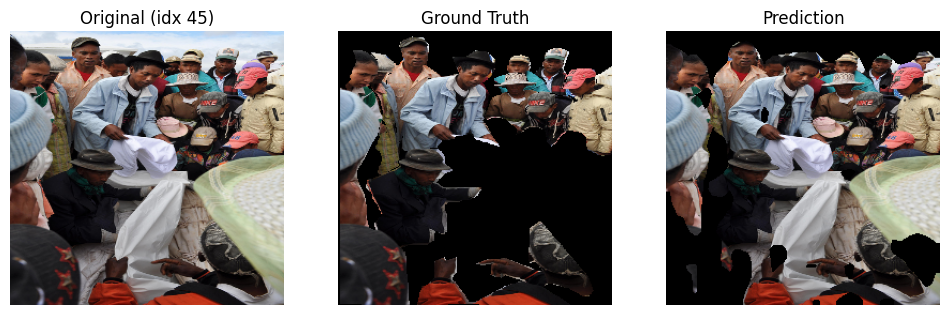

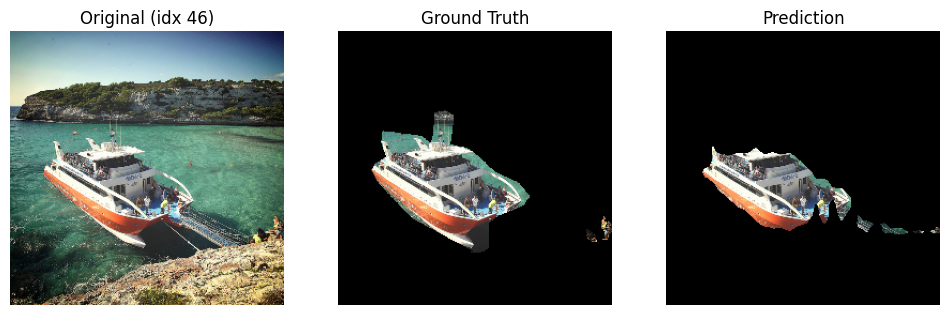

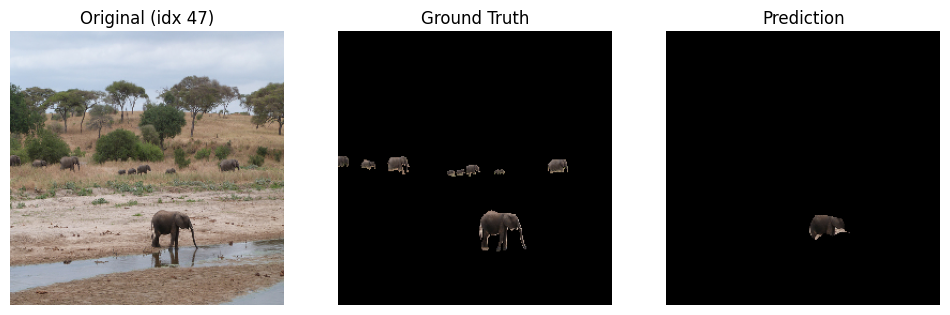

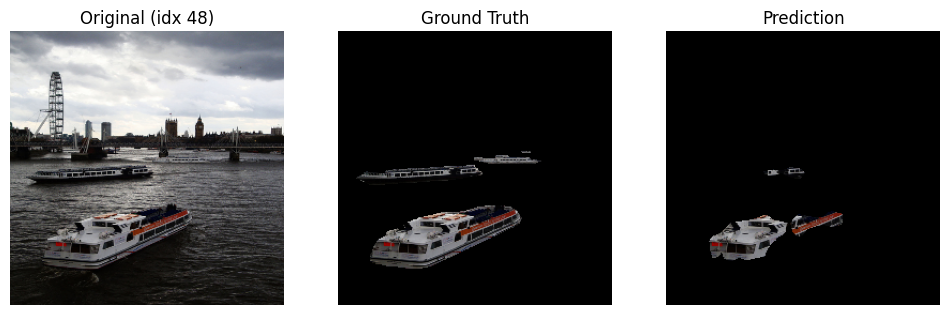

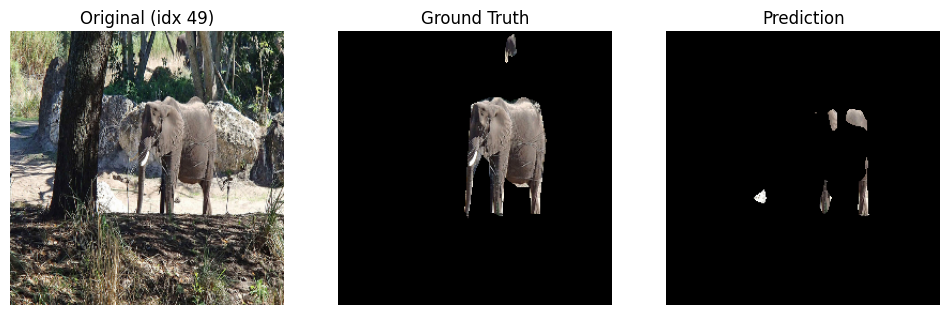

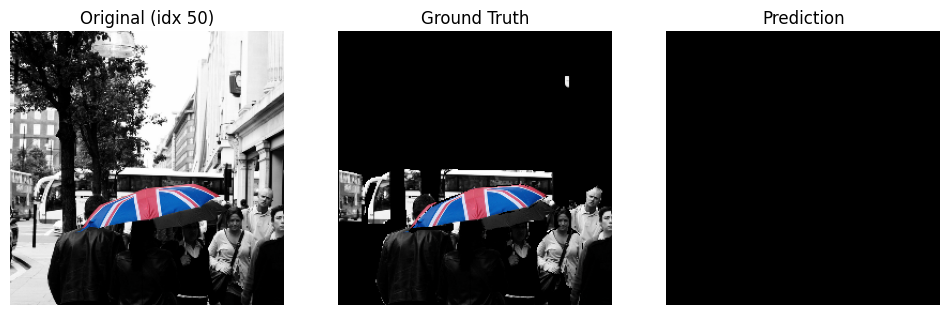

In [ ]:
# === Fine-tune classifier head only (run this cell) ===
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Subset, DataLoader
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Create a small training subset (50 samples or fewer if dataset smaller)
subset_size = min(50, len(dataset))
subset_indices = random.sample(range(len(dataset)), subset_size)
train_subset = Subset(dataset, subset_indices)
train_loader = DataLoader(train_subset, batch_size=4, shuffle=True, num_workers=2)

# Freeze everything except classifier and aux_classifier
for name, param in model.named_parameters():
    if ("classifier" in name) or ("aux_classifier" in name):
        param.requires_grad = True
    else:
        param.requires_grad = False

# Optimizer only for trainable params (the classifier head)
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
criterion = nn.CrossEntropyLoss()

# Train head for a few epochs
num_epochs = 30
model.train()
for epoch in range(num_epochs):
    running_loss = 0.0
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False)
    for images, masks in loop:
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        outputs = model(images)["out"]          # [B, C, H, W]
        loss = criterion(outputs, masks.long())
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        loop.set_postfix(loss=running_loss / (loop.n + 1))

    print(f"Epoch {epoch+1}/{num_epochs}  avg_loss: {running_loss/len(train_loader):.4f}")

# Save the fine-tuned-head checkpoint
torch.save(model.state_dict(), "best_deeplabv3_finetuned_head.pth")
print("✅ Saved: best_deeplabv3_finetuned_head.pth")

# === Quick evaluation + visualization for dataset indices 20–25 ===
model.eval()
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

with torch.no_grad():
    for idx in range(44, 50):   # indices 19→24 == dataset samples 20→25
        img, mask = dataset[idx]
        img_input = img.unsqueeze(0).to(device)
        mask = mask.to(device)

        outputs = model(img_input)["out"]
        pred = torch.argmax(outputs, dim=1).cpu().squeeze().numpy()

        # Un-normalize for display
        img = img.permute(1,2,0).cpu().numpy()
        img = np.clip(img * std + mean, 0, 1)
        gt = mask.cpu().numpy()

        # Apply mask overlays
        gt_overlay = np.zeros_like(img)
        gt_overlay[gt == 1] = img[gt == 1]
        # Show all predicted classes except background (class 0)
        pred_overlay = np.zeros_like(img)
        pred_overlay[pred != 0] = img[pred != 0]


        # Plot side-by-side
        fig, axs = plt.subplots(1,3, figsize=(12,4))
        axs[0].imshow(img); axs[0].set_title(f"Original (idx {idx+1})"); axs[0].axis("off")
        axs[1].imshow(gt_overlay); axs[1].set_title("Ground Truth"); axs[1].axis("off")
        axs[2].imshow(pred_overlay); axs[2].set_title("Prediction"); axs[2].axis("off")
        plt.show()


Epoch 1/30  avg_loss: 0.5015


Epoch 2/30  avg_loss: 0.3238


Epoch 3/30  avg_loss: 0.3154


Epoch 4/30  avg_loss: 0.2550


Epoch 5/30  avg_loss: 0.2321


...

Epoch 26/30  avg_loss: 0.1343


Epoch 27/30  avg_loss: 0.1225


Epoch 28/30  avg_loss: 0.1172


Epoch 29/30  avg_loss: 0.1262


Epoch 30/30  avg_loss: 0.1109
✅ Saved: best_deeplabv3_finetuned_head.pth


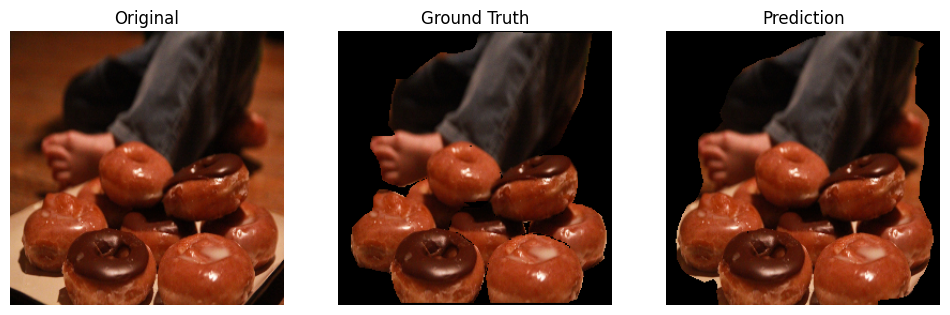

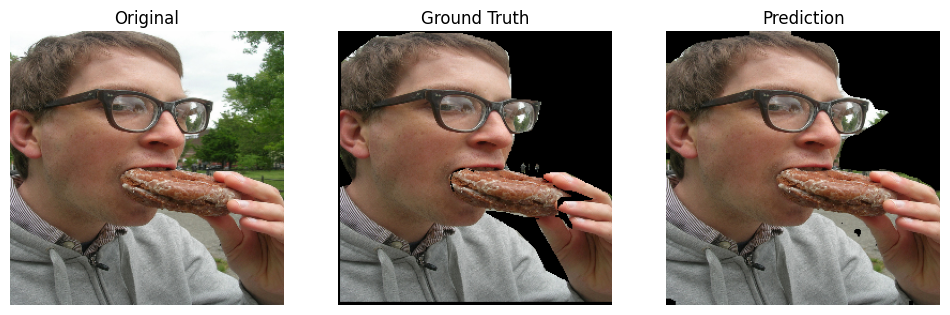

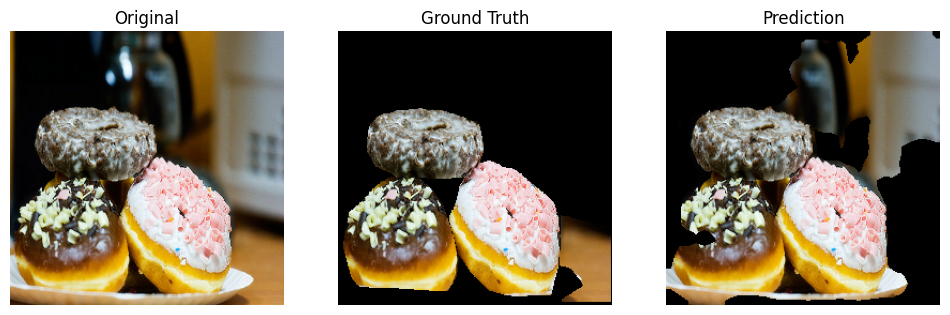

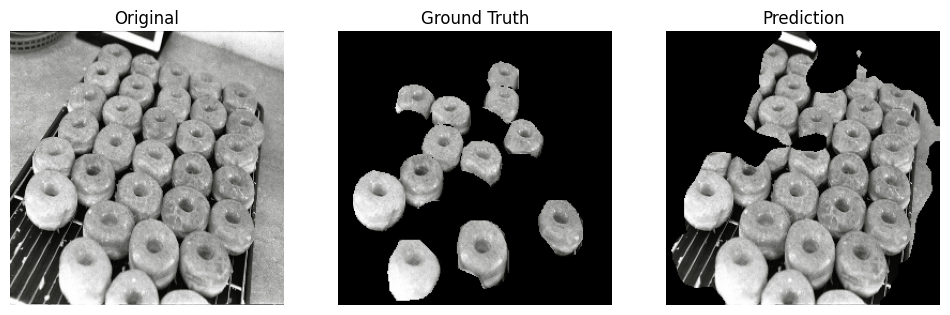

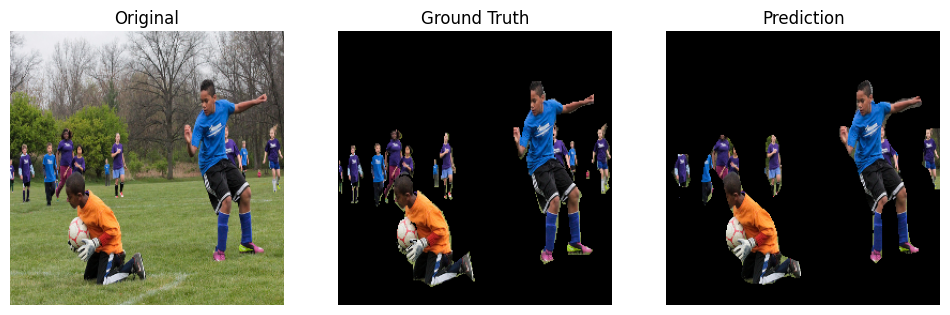

In [ ]:
# === Fine-tune classifier head only ===
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Subset, DataLoader
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# --- Create a small training subset (100 samples or fewer if dataset smaller)
subset_size = min(100, len(dataset))
subset_indices = random.sample(range(len(dataset)), subset_size)
train_subset = Subset(dataset, subset_indices)
train_loader = DataLoader(train_subset, batch_size=4, shuffle=True, num_workers=2)

# --- Freeze backbone, only train classifier heads
for name, param in model.named_parameters():
    if ("classifier" in name) or ("aux_classifier" in name):
        param.requires_grad = True
    else:
        param.requires_grad = False

# --- Optimizer & loss
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
criterion = nn.CrossEntropyLoss()

# --- Training loop
num_epochs = 30
model.train()
for epoch in range(num_epochs):
    running_loss = 0.0
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False)
    for images, masks in loop:
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        outputs = model(images)["out"]          # [B, C, H, W]
        loss = criterion(outputs, masks.long())
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        loop.set_postfix(loss=running_loss / (loop.n + 1))

    print(f"Epoch {epoch+1}/{num_epochs}  avg_loss: {running_loss/len(train_loader):.4f}")

# --- Save checkpoint
torch.save(model.state_dict(), "best_deeplabv3_finetuned_head.pth")
print("✅ Saved: best_deeplabv3_finetuned_head.pth")

# ======================================================
# === Evaluation & visualization for selected indices ===
# ======================================================

mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

model.eval()
with torch.no_grad():
    # 🔹 choose which indices to visualize
    selected_indices = [73, 74, 75, 77, 88]

    for idx in selected_indices:
        img, mask = dataset[idx]
        img_in = img.unsqueeze(0).to(device)
        mask = mask.to(device)

        outputs = model(img_in)["out"]
        pred = torch.argmax(outputs, dim=1).cpu().squeeze().numpy()

        # --- Un-normalize for display
        img_disp = img.permute(1,2,0).cpu().numpy()
        img_disp = np.clip(img_disp * std + mean, 0, 1)
        gt = mask.cpu().numpy()

        # --- Overlay (cutout style: keep original pixels where mask==class, else black)
        gt_overlay = np.zeros_like(img_disp)
        gt_overlay[gt == 1] = img_disp[gt == 1]

        pred_overlay = np.zeros_like(img_disp)
        pred_overlay[pred != 0] = img_disp[pred != 0]   # show all classes except background

        # --- Plot side-by-side
        fig, axs = plt.subplots(1,3, figsize=(12,4))
        axs[0].imshow(img_disp); axs[0].set_title(f"Original"); axs[0].axis("off")
        axs[1].imshow(gt_overlay); axs[1].set_title("Ground Truth"); axs[1].axis("off")
        axs[2].imshow(pred_overlay); axs[2].set_title("Prediction"); axs[2].axis("off")
        plt.show()


In [ ]:
import torch
import numpy as np
from tqdm import tqdm

# ================================
# Metrics Implementation
# ================================
def evaluate_model(model, dataloader, device, num_classes=2):
    model.eval()
    iou_list = []
    dice_list = []
    total_correct = 0
    total_pixels = 0

    with torch.no_grad():
        for images, masks in tqdm(dataloader, desc="Evaluating"):
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)["out"]
            preds = torch.argmax(outputs, dim=1)

            for pred, mask in zip(preds, masks):
                pred = pred.cpu().numpy()
                mask = mask.cpu().numpy()

                for cls in range(1, num_classes):  # skip background (class 0)
                    pred_cls = (pred == cls).astype(np.uint8)
                    mask_cls = (mask == cls).astype(np.uint8)

                    intersection = np.logical_and(pred_cls, mask_cls).sum()
                    union = np.logical_or(pred_cls, mask_cls).sum()
                    dice = (2 * intersection) / (pred_cls.sum() + mask_cls.sum() + 1e-6)

                    if union > 0:  # avoid division by zero
                        iou_list.append(intersection / union)
                    dice_list.append(dice)

                # Pixel accuracy
                total_correct += (pred == mask).sum()
                total_pixels += mask.size

    mean_iou = np.mean(iou_list) if iou_list else 0
    mean_dice = np.mean(dice_list) if dice_list else 0
    pixel_acc = total_correct / total_pixels

    return mean_iou, mean_dice, pixel_acc


# ================================
# Run Evaluation
# ================================
mean_iou, mean_dice, pixel_acc = evaluate_model(model, val_loader, device, num_classes=2)

print(f"✅ Evaluation Results:")
print(f"Mean IoU:   {mean_iou:.4f}")
print(f"Mean Dice:  {mean_dice:.4f}")
print(f"Pixel Acc:  {pixel_acc:.4f}")


Evaluating: 100%|██████████| 2500/2500 [06:55<00:00,  6.01it/s]

✅ Evaluation Results:
Mean IoU:   0.5518
Mean Dice:  0.6693
Pixel Acc:  0.8568
